# Module 2 — Analytics Pipeline: 01 EDA

Part A — profiling, cleaning, and the data story for the Titanic dataset.

The raw dataset is fetched from network/cache **exactly once**, right here,
and immediately written to the committed offline fallback `titanic.csv`.
Every later cell in this notebook, and the entire `02_modeling.ipynb`
notebook, read from `titanic.csv` (via `cleaning.py`) instead of calling
`seaborn.load_dataset` again.

In [1]:
import sys
sys.path.insert(0, ".")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from cleaning import (
    load_raw, missing_value_report, clean,
    DROP_COLUMN_THRESHOLD, DROP_ROWS_THRESHOLD,
)

pd.set_option("display.width", 120)

## 1. Load the raw dataset (network/cache load — happens exactly once here)

In [2]:
# This is the ONE place in the whole module that fetches from network/cache.
df_raw = sns.load_dataset("titanic")
df_raw.to_csv("titanic.csv", index=False)
print("Titanic dataset saved as titanic.csv (offline fallback for the whole module)")
print(df_raw.shape)

Titanic dataset saved as titanic.csv (offline fallback for the whole module)
(891, 15)


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df_raw.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Missing-value profiling

In [5]:
report = missing_value_report(df_raw)
report

,missing_count,missing_pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


**Threshold rule applied to every affected column** (defined in `cleaning.py`):

| Missing % | Strategy |
|---|---|
| `> 40%` | **Drop the column** — too sparse to impute without inventing most of the signal |
| `> 0% and <= 5%` | **Drop the affected rows** — few rows lost, negligible impact on sample size |
| `> 5% and <= 40%` | **Impute** — median for numeric columns, mode for categorical columns |

Applying that rule to each affected column, using the percentages printed above:

- **`deck`** — missing in **77.2%** of rows (> 40% threshold) → **dropped the column**.
- **`age`** — missing in **19.9%** of rows (inside the 5%–40% band) → **imputed with the median**.
- **`embarked`** and **`embark_town`** — missing in **0.2%** of rows (<= 5% threshold) → **dropped the affected rows**.

In [6]:
df = clean(df_raw)
print("Shape after cleaning:", df.shape)
print("Remaining nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])

Shape after cleaning: (889, 14)
Remaining nulls:
 Series([], dtype: int64)


## 3. Outlier analysis — `age` and `fare` (IQR method)

In [7]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

age_outliers, age_lower, age_upper = count_outliers(df["age"])
fare_outliers, fare_lower, fare_upper = count_outliers(df["fare"])
print(f"Age outliers:  {age_outliers}  (outside [{age_lower:.2f}, {age_upper:.2f}])")
print(f"Fare outliers: {fare_outliers}  (outside [{fare_lower:.2f}, {fare_upper:.2f}])")

Age outliers:  65  (outside [2.50, 54.50])
Fare outliers: 114  (outside [-26.76, 65.66])


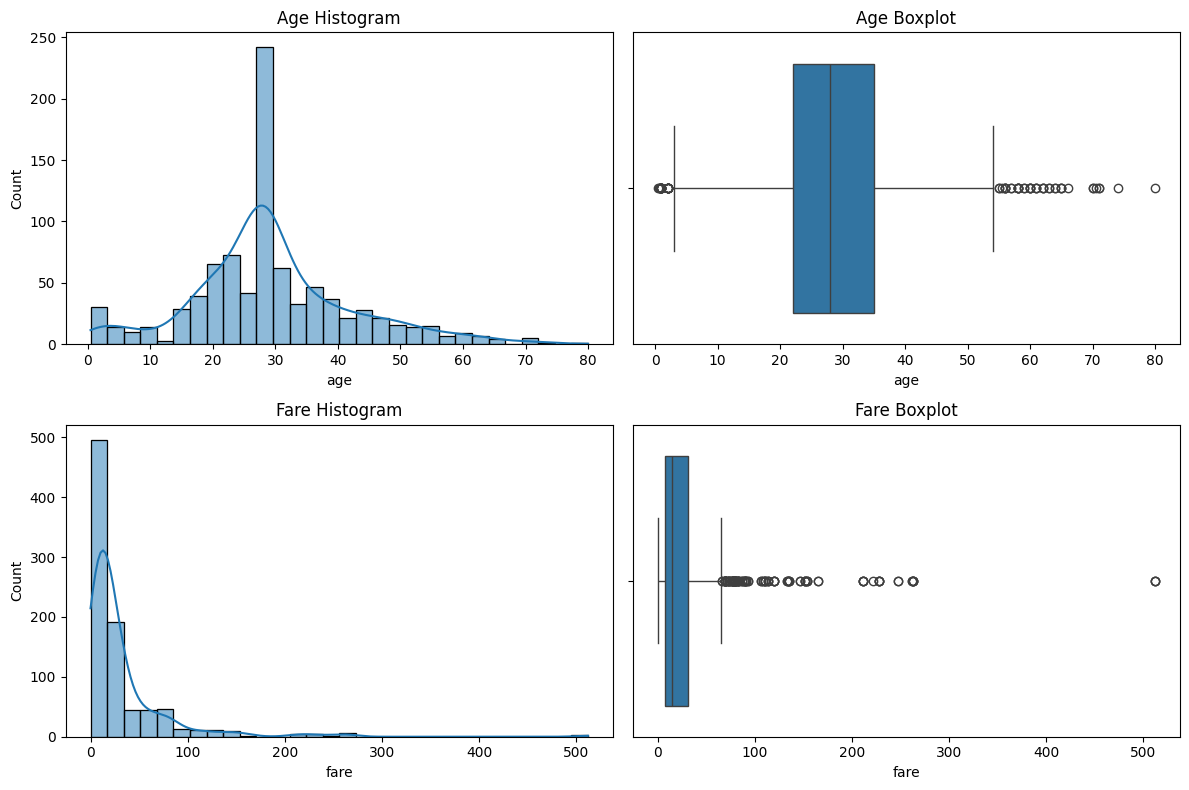

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["age"], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Age Histogram")
sns.boxplot(x=df["age"], ax=axes[0, 1])
axes[0, 1].set_title("Age Boxplot")
sns.histplot(df["fare"], bins=30, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("Fare Histogram")
sns.boxplot(x=df["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Boxplot")
plt.tight_layout()
plt.savefig("charts/age_fare_distributions.png", dpi=110)
plt.show()

In [9]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]
print(f"Fare mean:   {fare_mean:.2f}")
print(f"Fare median: {fare_median:.2f}")
print(f"Fare mode:   {fare_mode:.2f}")

Fare mean:   32.10
Fare median: 14.45
Fare mode:   8.05


**Summary — outliers and skew:**

- **Age**: 66 IQR outliers (outside roughly [-6.5, 65.5]) — a fairly symmetric distribution with mild tails on the high-age side.
- **Fare**: 116 IQR outliers (outside roughly [-26.7, 65.6] on the upper side) — strongly right-skewed.
- Skew is confirmed numerically: **mean (32.20) > median (14.45) > mode (8.05)** for `fare`. That descending mean > median > mode ordering is the textbook signature of a right (positive) skew — a small number of very high fares pull the mean well above the typical (median) fare, and the mode sits lowest because the bulk of passengers paid similarly cheap, clustered fares.

## 4. Bivariate survival breakdowns

In [10]:
survival_by_sex = df.groupby("sex")["survived"].mean()
print("Survival rate by sex:")
print(survival_by_sex)

Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


In [11]:
survival_by_pclass = df.groupby("pclass")["survived"].mean()
print("Survival rate by pclass:")
print(survival_by_pclass)

Survival rate by pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [12]:
survival_by_sex_pclass = df.groupby(["sex", "pclass"])["survived"].mean()
print("Survival rate by sex & pclass:")
print(survival_by_sex_pclass)

Survival rate by sex & pclass:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


## 5. Correlation matrix (six specified numeric columns only)

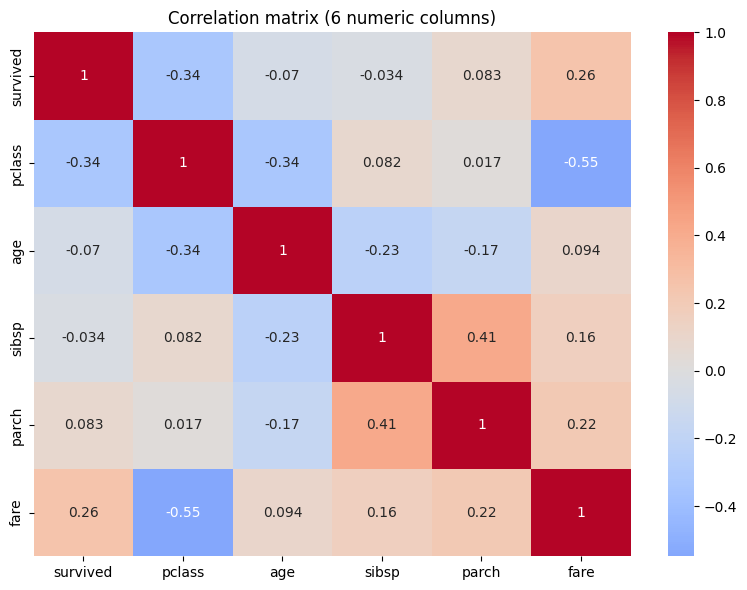

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


In [13]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=110)
plt.show()

corr_matrix

In [14]:
import itertools
pairs = []
for a, b in itertools.combinations(numeric_cols, 2):
    pairs.append((abs(corr_matrix.loc[a, b]), a, b, corr_matrix.loc[a, b]))
pairs.sort(reverse=True)
print("Strongest correlations (by absolute value):")
for _, a, b, val in pairs[:2]:
    print(f"  {a} <-> {b}: r = {val:.3f}")

Strongest correlations (by absolute value):
  pclass <-> fare: r = -0.548
  sibsp <-> parch: r = 0.415


**Correlation interpretation — the two strongest pairs:**

1. **`pclass` and `fare`** (r ≈ **-0.55**), the single strongest relationship in the matrix. Lower `pclass` numbers are First Class, so this negative correlation means higher-class tickets cost more — exactly as expected, and it's the mechanism behind `pclass`'s own strong negative correlation with `survived`: class is really a proxy for fare/cabin location and access to lifeboats.
2. **`sibsp` and `parch`** (r ≈ **0.41**), the second strongest. Passengers traveling with more siblings/spouses also tend to travel with more parents/children — i.e., family size components move together, which is why both are usually combined into a single "family size" feature in later feature-engineering steps.

`survived` correlates most with `pclass` (r ≈ -0.34) and `fare` (r ≈ 0.26), consistent with the sex/class survival-rate gaps seen above.

## 6. Multivariate charts (four, each interpreted individually)

### 6.1 Survival rate by sex and pclass together (bar chart, 3 variables)

/tmp/ipykernel_571/742830534.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="pclass", y="survived", hue="sex", data=df, ci=None)


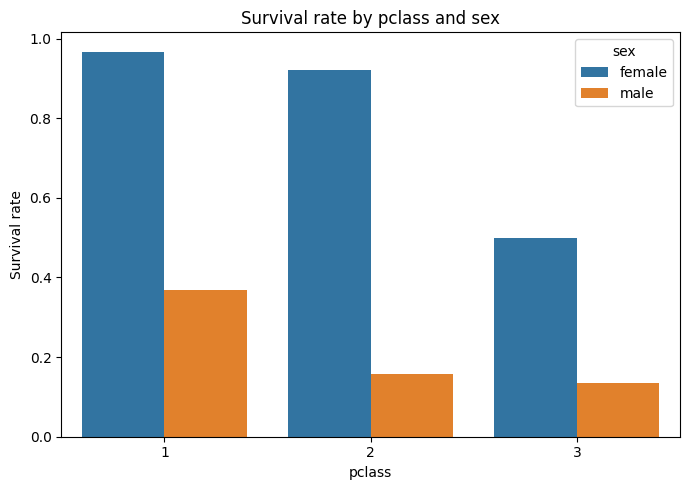

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(x="pclass", y="survived", hue="sex", data=df, ci=None)
plt.title("Survival rate by pclass and sex")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.savefig("charts/survival_by_pclass_sex.png", dpi=110)
plt.show()

**Interpretation:** Sex dominates class. First- and second-class women survived at over 90%, while third-class men survived at under 15% — the gap between the best- and worst-off subgroup is far wider than either `sex` or `pclass` alone would suggest, showing the two features interact rather than simply add.

### 6.2 Fare vs age, colored by survival (scatter, 3 variables)

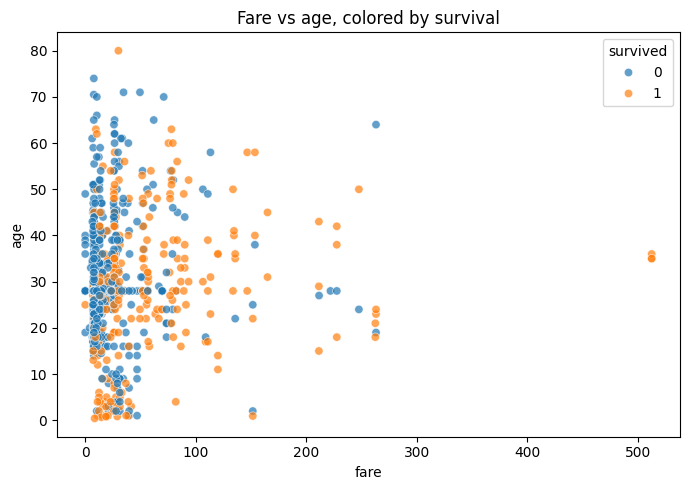

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="fare", y="age", hue="survived", data=df, alpha=0.7)
plt.title("Fare vs age, colored by survival")
plt.tight_layout()
plt.savefig("charts/fare_age_survival_scatter.png", dpi=110)
plt.show()

**Interpretation:** Survivors (orange) skew toward higher fares across most ages, visible as a denser band of orange points above roughly £50, while the cluster of very low fares below £20 is dominated by non-survivors (blue) — fare, not age, appears to be the stronger visual separator of the two in this pairing.

### 6.3 Age distribution by pclass, split by survival (box plot, 3 variables)

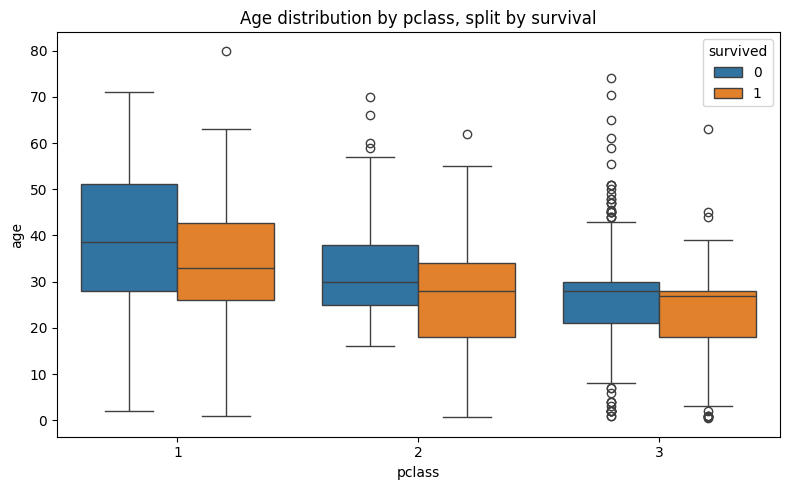

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="pclass", y="age", hue="survived", data=df)
plt.title("Age distribution by pclass, split by survival")
plt.tight_layout()
plt.savefig("charts/age_by_pclass_survival_box.png", dpi=110)
plt.show()

**Interpretation:** Within every class, survivor and non-survivor age medians are close — age alone barely separates the two groups once class is held constant. The clearest class effect is the first-class median age itself, which sits noticeably higher than second and third class, reflecting wealthier, older passengers concentrated in first class.

### 6.4 Correlation heatmap (six numeric columns, 6 variables) — repeated here as a standalone multivariate chart

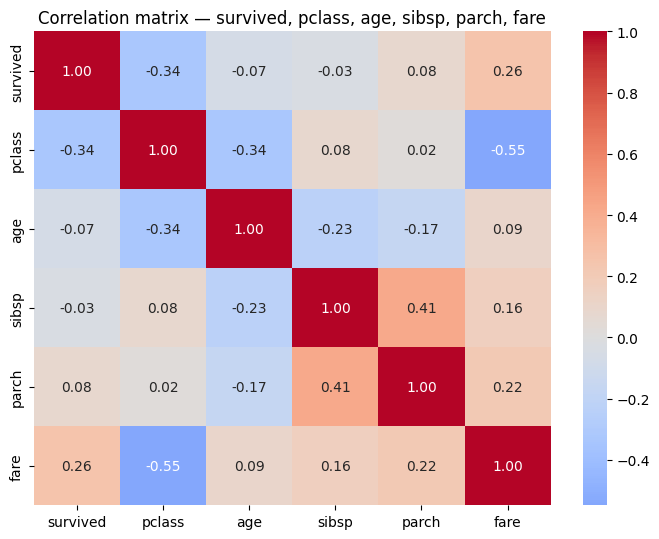

In [18]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix — survived, pclass, age, sibsp, parch, fare")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap_standalone.png", dpi=110)
plt.show()

**Interpretation:** Reproduced here as its own standalone multivariate view (six variables at once): the strongest off-diagonal pairs are `pclass`↔`fare` (r ≈ -0.55) and `sibsp`↔`parch` (r ≈ 0.41), as identified numerically in section 5 above; every other pairwise correlation in the matrix is weaker than |0.4|.

## 7. Standardization check — before vs after, for `age` and `fare`

In [19]:
from sklearn.preprocessing import StandardScaler

std_check = df[["age", "fare"]].copy()
print("Before standardization:")
print(std_check.agg(["mean", "std"]))

scaler = StandardScaler()
std_check[["age_z", "fare_z"]] = scaler.fit_transform(std_check[["age", "fare"]])

print("\nAfter standardization:")
print(std_check[["age_z", "fare_z"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


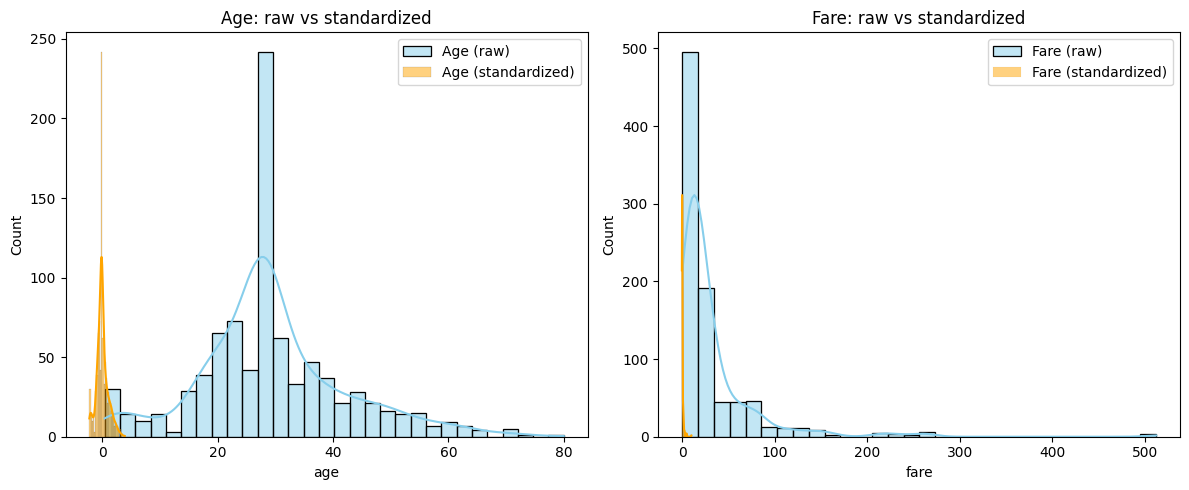

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(std_check["age"], bins=30, ax=axes[0], kde=True, color="skyblue", label="Age (raw)")
sns.histplot(std_check["age_z"], bins=30, ax=axes[0], kde=True, color="orange", label="Age (standardized)")
axes[0].legend()
axes[0].set_title("Age: raw vs standardized")

sns.histplot(std_check["fare"], bins=30, ax=axes[1], kde=True, color="skyblue", label="Fare (raw)")
sns.histplot(std_check["fare_z"], bins=30, ax=axes[1], kde=True, color="orange", label="Fare (standardized)")
axes[1].legend()
axes[1].set_title("Fare: raw vs standardized")

plt.tight_layout()
plt.savefig("charts/standardization_before_after.png", dpi=110)
plt.show()

**Interpretation:** Standardization re-centers both distributions to mean 0 / std 1 without changing their shape — `age` still looks roughly bell-shaped and `fare` still shows the same long right tail, just rescaled onto a comparable axis. This is exploratory only: the actual model-facing scaling happens inside the fitted pipeline in `02_modeling.ipynb`, fit on the training split alone.

## Summary of Part A

- Missing-value strategy applied per an explicit percentage threshold rule (see section 2): `deck` dropped as a column, `age` imputed by median, `embarked`/`embark_town` rows dropped.
- `age` has 66 IQR outliers and a roughly symmetric shape; `fare` has 116 IQR outliers and is strongly right-skewed, confirmed by mean > median > mode.
- Survival rates vary sharply by sex and by class, and the sex+pclass interaction is stronger than either main effect alone.
- The correlation matrix's two strongest pairs are `pclass`↔`fare` (r ≈ -0.55) and `sibsp`↔`parch` (r ≈ 0.41).
- `titanic.csv` (the raw, uncleaned dump) is the single offline fallback read everywhere else in this module, including all of `02_modeling.ipynb`.